In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

# Preprocessing & Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)


In [2]:
data = pd.read_csv('clean.csv')

Dataset loaded: 11000 rows, 20 columns
Features (X): 18 columns
Target (y) distribution:
Anxiety_Class
0    5202
1    4661
2    1137
Name: count, dtype: int64

Class balance ratio (%):
Anxiety_Class
0    47.29
1    42.37
2    10.34
Name: count, dtype: float64

Class balance ratio: 5202:4661:1137 (Low : Moderate : High)


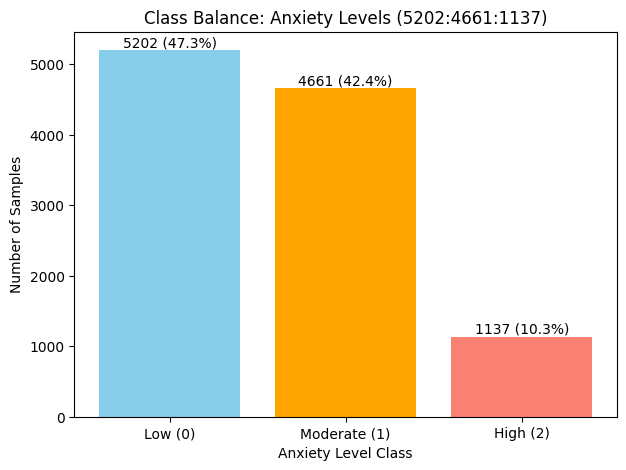

In [3]:
def anxiety_category(x):
    if x <= 3:
        return 0  # Low
    elif x <= 6:
        return 1  # Moderate
    else:
        return 2  # High

data["Anxiety_Class"] = data["Anxiety Level (1-10)"].apply(anxiety_category)
X = data.drop(["Anxiety Level (1-10)", "Anxiety_Class"], axis=1)
y = data["Anxiety_Class"]

# --- Counts and ratios ---
counts = y.value_counts().sort_index()
class_ratio = counts / counts.sum()

# Simplified ratio
g = gcd(counts[0], counts[1]) if len(counts) > 1 else 1
ratio_str = ':'.join(str(counts[i]//g) for i in range(len(counts)))

# --- Print info ---
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y) distribution:\n{counts}")
print("\nClass balance ratio (%):")
print((class_ratio * 100).round(2))
print(f"\nClass balance ratio: {ratio_str} (Low : Moderate : High)")

# --- Plot ---
plt.figure(figsize=(7,5))
bars = plt.bar(counts.index.astype(str), counts.values, color=['skyblue','orange','salmon'])
plt.title(f"Class Balance: Anxiety Levels ({ratio_str})")
plt.xlabel("Anxiety Level Class")
plt.ylabel("Number of Samples")
plt.xticks([0,1,2], ["Low (0)", "Moderate (1)", "High (2)"])

# Add count + percentage on top
for bar, ratio in zip(bars, class_ratio):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f"{int(height)} ({ratio*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.show()

Identify categorical and numeric columns

In [4]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

ONEHOTENCODING AND FEASURE SCALING

In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

SPLITTING THE DATASET INTO TEST AND TRAIN SET

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


TRAIN THE MODEL

In [7]:
pipelines = {
    "logreg": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        ))
    ]),

    "svm": Pipeline([
        ("preprocess", preprocess),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=5000
        ))
    ]),

    "xgb": Pipeline([
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42
        ))
    ]),

    "mlp": Pipeline([
        ("preprocess", preprocess),
        ("model", MLPClassifier(
            max_iter=1000,
            random_state=42
        ))
    ])
}




In [8]:
param_grids = {
    "logreg": {
        "model__C": [0.01, 0.1, 1]
    },

    "svm": {
        "model__C": [0.01, 0.1, 1]
    },

    "mlp": {
        "model__hidden_layer_sizes": [(50,), (100,)],
        "model__alpha": [0.0001, 0.001]
    },

    "xgb": {
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [200]
    }
}

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [10]:
results = {}

for name, pipe in pipelines.items():
    print(f"\nRunning CV for: {name.upper()}")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    results[name] = grid

    print(f"Best CV F1-macro: {grid.best_score_:.4f}")
    print(f"Best params: {grid.best_params_}")



Running CV for: LOGREG
Fitting 5 folds for each of 3 candidates, totalling 15 fits


Best CV F1-macro: 0.8008
Best params: {'model__C': 0.01}

Running CV for: SVM
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV F1-macro: 0.8036
Best params: {'model__C': 1}

Running CV for: XGB
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best CV F1-macro: 0.8242
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}

Running CV for: MLP
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/workspaces/DECLINE/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/workspaces/DECLINE/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Best CV F1-macro: 0.7784
Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,)}


In [11]:
best_model_name = max(results, key=lambda x: results[x].best_score_)
best_model = results[best_model_name].best_estimator_

print(f"\nBest overall model: {best_model_name.upper()}")

y_pred = best_model.predict(X_test)

print("\nTest set performance:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))



Best overall model: XGB

Test set performance:
              precision    recall  f1-score   support

         Low       0.78      0.77      0.77      1041
    Moderate       0.72      0.75      0.74       932
        High       0.98      0.88      0.93       227

    accuracy                           0.77      2200
   macro avg       0.83      0.80      0.81      2200
weighted avg       0.78      0.77      0.77      2200

